## Analyze the gender skew of history vs retrieved

In [2]:
import pandas as pd
import numpy as np
import json
from sklearn.metrics.pairwise import cosine_similarity

# import chromadb
pd.set_option('display.max_columns', None)
# TODO: Add gender to chromadb metadata

In [3]:
user_df_pickle_path = '/Users/jessicakahn/Documents/repos/MIND/data/retrieved_user.pkl'
user_df = pd.read_pickle(user_df_pickle_path)

In [4]:
news = pd.read_csv('/Users/jessicakahn/Documents/repos/MIND/data/news_processed.csv')
gender_dict = news.set_index('NewsID')['Gender'].to_dict()

In [5]:
user_df.head(5)

,ImpressionID,UserID,Time,History,Impressions,history_list,history_len,hist_,history_gender,records,averaged_embed,retrieved,retrieved_gender
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[N31739, N6072, N63045, N23979, N35656, N43353...",82.0,"[N48390, N58224, N48742, N35458, N24611, N3750...","[Neutral, Neutral, M, Neutral, F, M, Neutral, ...","{'ids': ['N35458', 'N37509', 'N48742', 'N24611...","[-0.022237273445352913, 0.06586747923865914, -...","{'ids': [['N43585', 'N25785', 'N19041', 'N3188...","[Neutral, Neutral, Neutral, M, Neutral, Neutra..."
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[N10732, N25792, N7563, N21087, N41087, N5445,...",16.0,"[N60384, N46616, N52500, N33164, N47289, N2423...","[Neutral, Neutral, Neutral, Neutral, Neutral, ...","{'ids': ['N24233', 'N49475', 'N46616', 'N52500...","[0.017427177540957926, 0.031492797564715146, 0...","{'ids': [['N52500', 'N18870', 'N24233', 'N4139...","[Neutral, Neutral, Neutral, Neutral, Neutral, ..."
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[N45729, N2203, N871, N53880, N41375, N43142, ...",10.0,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[Neutral, Neutral, M, Neutral, Neutral, Neutra...","{'ids': ['N53880', 'N45729', 'N33013', 'N43142...","[-0.026858700846787542, 0.013809896679595113, ...","{'ids': [['N2203', 'N3149', 'N36352', 'N46011'...","[Neutral, Neutral, Neutral, Neutral, Neutral, ..."
5,6,U19739,11/11/2019 6:52:13 PM,N39074 N14343 N32607 N32320 N22007 N442 N19001...,N21119-1 N53696-0 N33619-1 N25722-0 N2869-0,"[N39074, N14343, N32607, N32320, N22007, N442,...",36.0,"[N42512, N58521, N62846, N14385, N47020, N2142...","[M, Neutral, Neutral, Neutral, Neutral, Neutra...","{'ids': ['N42512', 'N62846', 'N58521', 'N52121...","[-0.023250294021434255, 0.03033571145755963, 0...","{'ids': [['N17511', 'N62103', 'N39650', 'N5852...","[Neutral, Neutral, Neutral, Neutral, Neutral, ..."
6,7,U8355,11/11/2019 12:22:09 PM,N8419 N15771 N1431 N5888 N18663 N24123 N22130 ...,N51346-0 N33848-0 N15132-0 N10688-0 N6342-0 N6...,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",35.0,"[N306, N30160, N41797, N47482, N2606, N20886, ...","[M, Neutral, Neutral, M, F, M, Neutral, Neutra...","{'ids': ['N47482', 'N306', 'N20886', 'N41797',...","[-0.014741261675953864, 0.053519477136433125, ...","{'ids': [['N2606', 'N47482', 'N40410', 'N1854'...","[F, M, Neutral, Neutral, Neutral, Neutral, Neu..."


In [6]:
# len_hist = 

In [7]:
user_df['hist_count_neut'] = user_df['history_gender'].apply(lambda x: x.count('Neutral'))
user_df['hist_count_male'] = user_df['history_gender'].apply(lambda x: x.count('M'))
user_df['hist_count_female'] = user_df['history_gender'].apply(lambda x: x.count('F'))

user_df['ret_count_neut'] = user_df['retrieved_gender'].apply(lambda x: x.count('Neutral'))
user_df['ret_count_male'] = user_df['retrieved_gender'].apply(lambda x: x.count('M'))
user_df['ret_count_female'] = user_df['retrieved_gender'].apply(lambda x: x.count('F'))

In [8]:
user_df['hist_neut_prop'] = user_df['hist_count_neut']/10
user_df['hist_male_prop'] = user_df['hist_count_male']/10
user_df['hist_female_prop'] = user_df['hist_count_female']/10

user_df['ret_neut_prop'] = user_df['ret_count_neut']/10
user_df['ret_male_prop'] = user_df['ret_count_male']/10
user_df['ret_female_prop'] = user_df['ret_count_female']/10

In [9]:
np.mean((user_df['ret_female_prop'] - round(user_df['hist_female_prop'],1)))

np.float64(-0.00014340040478848503)

<Axes: ylabel='Frequency'>

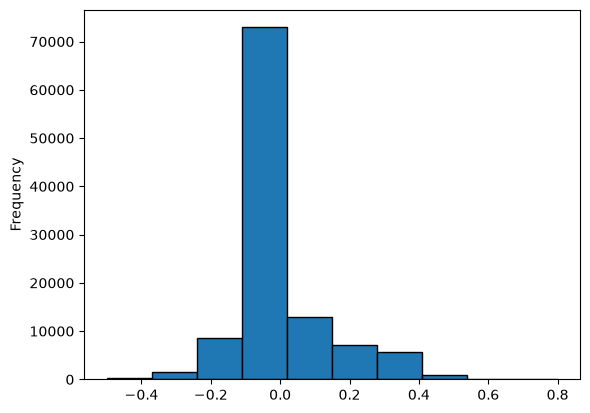

In [10]:
(user_df['ret_female_prop'] - user_df['hist_female_prop']).plot.hist( edgecolor='black')
# user_df.plot.scatter(x='hist_female_prop', y='ret_female_prop', alpha=0.5)

<Axes: ylabel='Frequency'>

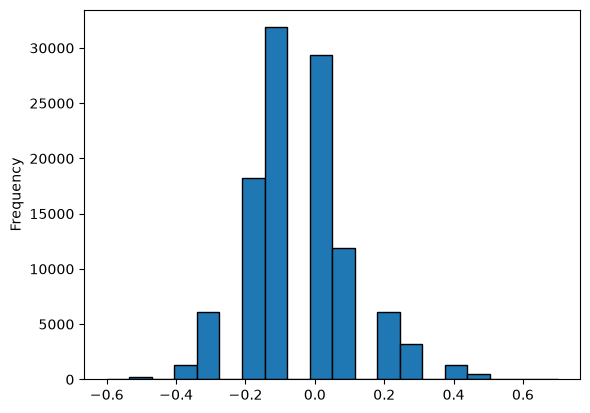

In [11]:
(user_df['ret_male_prop'] - user_df['hist_male_prop']).plot.hist(bins=20,edgecolor='black')


<Axes: ylabel='Frequency'>

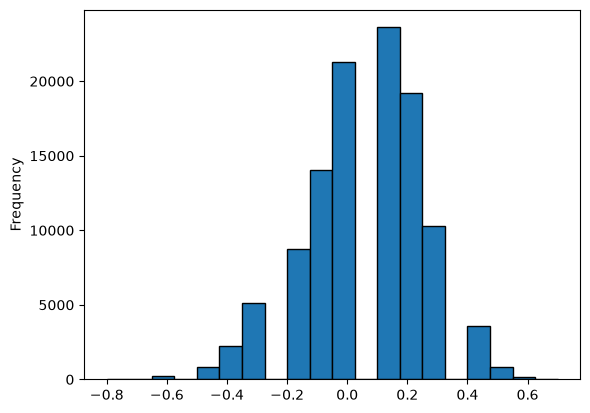

In [12]:
(user_df['ret_neut_prop'] - user_df['hist_neut_prop']).plot.hist(bins=20,edgecolor='black')

In [13]:
np.mean(user_df['ret_neut_prop']), np.mean(user_df['hist_neut_prop'])

(np.float64(0.7435764787032247), np.float64(0.6971183779417505))

In [14]:
np.mean(user_df['ret_male_prop']), np.mean(user_df['hist_male_prop'])

(np.float64(0.1447300351240232), np.float64(0.19104473548070902))

In [15]:
np.mean(user_df['ret_female_prop']), np.mean(user_df['hist_female_prop'])

(np.float64(0.11169348617275211), np.float64(0.11183688657754061))

In [16]:
np.sum(user_df['hist_count_neut']), np.sum(user_df['ret_count_neut'])

(np.int64(768092), np.int64(819280))

In [17]:
np.sum(user_df['hist_count_male']), np.sum(user_df['ret_count_male'])

(np.int64(210495), np.int64(159465))

In [18]:
np.sum(user_df['hist_count_female']), np.sum(user_df['ret_count_female'])

(np.int64(123223), np.int64(123065))

In [19]:
# Function that takes a single users records and returns the off-diag cosine sim mean
def off_diag_mean(records):
    sim_matrix = cosine_similarity(records['embeddings'])
    dim=sim_matrix.shape[0]
    off_diag = sim_matrix[~np.eye(dim, dtype=bool)]
    return off_diag.mean()


In [20]:
counter = 0
for i, row in user_df.iterrows():
    print(row['records']['embeddings'].shape[0])
    counter += 1
    if counter >= 5:
        break

10
10
10
9
10


In [21]:
user_df['off_diag'] = user_df['records'].apply(off_diag_mean)

In [22]:

# sim_matrix = cosine_similarity(user_df['records'].iloc[0]['embeddings'])
# user_df['retrieved'].iloc[0]


In [23]:
# sim_matrix.shape

In [24]:
off_diag = sim_matrix[~np.eye(10, dtype=bool)]
print(f"Mean off-diagonal similarity: {off_diag.mean():.3f}")

NameError: name 'sim_matrix' is not defined

<Axes: >

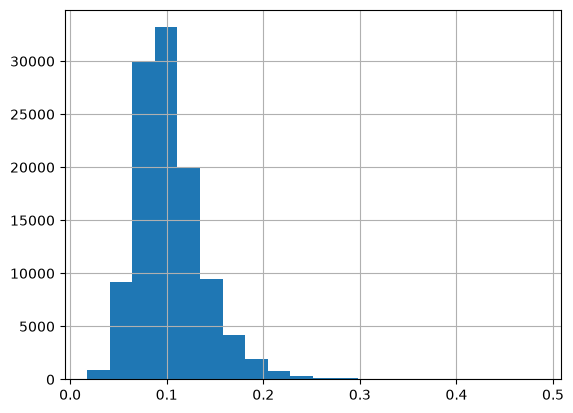

In [ ]:
user_df['off_diag'].hist(bins=20)

In [ ]:
user_df['off_diag_bin'] = pd.cut(user_df['off_diag'],bins=5)

In [ ]:
bins = user_df['off_diag_bin'].unique()
bins

[(0.111, 0.205], (0.0173, 0.111], (0.205, 0.298], (0.298, 0.391], (0.391, 0.485]]
Categories (5, interval[float64, right]): [(0.0173, 0.111] < (0.111, 0.205] < (0.205, 0.298] < (0.298, 0.391] < (0.391, 0.485]]

In [ ]:
for g in ('male','female','neut'):
    print(user_df.groupby('off_diag_bin')[[f'hist_{g}_prop',f'ret_{g}_prop']].mean())

                 hist_male_prop  ret_male_prop
off_diag_bin                                  
(0.0173, 0.111]        0.185529       0.133223
(0.111, 0.205]         0.201793       0.166462
(0.205, 0.298]         0.213004       0.198887
(0.298, 0.391]         0.134921       0.102381
(0.391, 0.485]         0.000000       0.000000
                 hist_female_prop  ret_female_prop
off_diag_bin                                      
(0.0173, 0.111]          0.107434         0.110635
(0.111, 0.205]           0.122125         0.116379
(0.205, 0.298]           0.088526         0.060083
(0.298, 0.391]           0.048413         0.007143
(0.391, 0.485]           0.000000         0.000000
                 hist_neut_prop  ret_neut_prop
off_diag_bin                                  
(0.0173, 0.111]        0.707037       0.756142
(0.111, 0.205]         0.676082       0.717160
(0.205, 0.298]         0.698470       0.741029
(0.298, 0.391]         0.816667       0.890476
(0.391, 0.485]         1.000000 

In [ ]:
# [['ret_male_prop','ret_neut_prop','ret_female_prop']]
for g in ('male','female','neut'):
    print(user_df.groupby(f'hist_{g}_prop').agg(
        total_count = ('ImpressionID','count'),
        ret_male_prop = ('ret_male_prop','mean'),
        ret_neut_prop = ('ret_neut_prop','mean'),
        ret_female_prop = ('ret_female_prop','mean')

    )
    )

                total_count  ret_male_prop  ret_neut_prop  ret_female_prop
hist_male_prop                                                            
0.0                   16238       0.029117       0.862538         0.108345
0.1                   30663       0.074115       0.809448         0.116437
0.2                   29888       0.134840       0.746380         0.118780
0.3                   19518       0.218245       0.665545         0.116211
0.4                    9369       0.314815       0.593660         0.091525
0.5                    3304       0.408898       0.517191         0.073910
0.6                     946       0.489429       0.458140         0.052431
0.7                     214       0.554673       0.411215         0.034112
0.8                      37       0.743243       0.256757         0.000000
0.9                       4       0.400000       0.600000         0.000000
                  total_count  ret_male_prop  ret_neut_prop  ret_female_prop
hist_female_prop       

In [ ]:
user_df.groupby('hist_male_prop')[['ret_male_prop','ret_neut_prop','ret_female_prop']].mean()

,ret_male_prop,ret_neut_prop,ret_female_prop
hist_male_prop,,,
0.0,0.029117,0.862538,0.108345
0.1,0.074115,0.809448,0.116437
0.2,0.134840,0.746380,0.118780
0.3,0.218245,0.665545,0.116211
0.4,0.314815,0.593660,0.091525
0.5,0.408898,0.517191,0.073910
0.6,0.489429,0.458140,0.052431
0.7,0.554673,0.411215,0.034112
0.8,0.743243,0.256757,0.000000


In [ ]:
user_df.head()

,ImpressionID,UserID,Time,History,Impressions,history_list,history_len,hist_,history_gender,records,averaged_embed,retrieved,retrieved_gender,hist_count_neut,hist_count_male,hist_count_female,ret_count_neut,ret_count_male,ret_count_female,hist_neut_prop,hist_male_prop,hist_female_prop,ret_neut_prop,ret_male_prop,ret_female_prop,off_diag,off_diag_bin
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[N31739, N6072, N63045, N23979, N35656, N43353...",82.0,"[N48390, N58224, N48742, N35458, N24611, N3750...","[Neutral, Neutral, M, Neutral, F, M, Neutral, ...","{'ids': ['N35458', 'N37509', 'N48742', 'N24611...","[-0.022237273445352913, 0.06586747923865914, -...","{'ids': [['N43585', 'N25785', 'N19041', 'N3188...","[Neutral, Neutral, Neutral, M, Neutral, Neutra...",6,3,1,9,1,0,0.6,0.3,0.1,0.9,0.1,0.0,0.138294,"(0.111, 0.205]"
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[N10732, N25792, N7563, N21087, N41087, N5445,...",16.0,"[N60384, N46616, N52500, N33164, N47289, N2423...","[Neutral, Neutral, Neutral, Neutral, Neutral, ...","{'ids': ['N24233', 'N49475', 'N46616', 'N52500...","[0.017427177540957926, 0.031492797564715146, 0...","{'ids': [['N52500', 'N18870', 'N24233', 'N4139...","[Neutral, Neutral, Neutral, Neutral, Neutral, ...",9,0,1,9,1,0,0.9,0.0,0.1,0.9,0.1,0.0,0.096395,"(0.0173, 0.111]"
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[N45729, N2203, N871, N53880, N41375, N43142, ...",10.0,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[Neutral, Neutral, M, Neutral, Neutral, Neutra...","{'ids': ['N53880', 'N45729', 'N33013', 'N43142...","[-0.026858700846787542, 0.013809896679595113, ...","{'ids': [['N2203', 'N3149', 'N36352', 'N46011'...","[Neutral, Neutral, Neutral, Neutral, Neutral, ...",9,1,0,10,0,0,0.9,0.1,0.0,1.0,0.0,0.0,0.078160,"(0.0173, 0.111]"
5,6,U19739,11/11/2019 6:52:13 PM,N39074 N14343 N32607 N32320 N22007 N442 N19001...,N21119-1 N53696-0 N33619-1 N25722-0 N2869-0,"[N39074, N14343, N32607, N32320, N22007, N442,...",36.0,"[N42512, N58521, N62846, N14385, N47020, N2142...","[M, Neutral, Neutral, Neutral, Neutral, Neutra...","{'ids': ['N42512', 'N62846', 'N58521', 'N52121...","[-0.023250294021434255, 0.03033571145755963, 0...","{'ids': [['N17511', 'N62103', 'N39650', 'N5852...","[Neutral, Neutral, Neutral, Neutral, Neutral, ...",8,1,1,9,1,0,0.8,0.1,0.1,0.9,0.1,0.0,0.070714,"(0.0173, 0.111]"
6,7,U8355,11/11/2019 12:22:09 PM,N8419 N15771 N1431 N5888 N18663 N24123 N22130 ...,N51346-0 N33848-0 N15132-0 N10688-0 N6342-0 N6...,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",35.0,"[N306, N30160, N41797, N47482, N2606, N20886, ...","[M, Neutral, Neutral, M, F, M, Neutral, Neutra...","{'ids': ['N47482', 'N306', 'N20886', 'N41797',...","[-0.014741261675953864, 0.053519477136433125, ...","{'ids': [['N2606', 'N47482', 'N40410', 'N1854'...","[F, M, Neutral, Neutral, Neutral, Neutral, Neu...",5,4,1,5,4,1,0.5,0.4,0.1,0.5,0.4,0.1,0.090178,"(0.0173, 0.111]"


### Analyze the breakdown of gender for history, retrieved and generated
Query the generated text and label the top matching candidates by gender?

In [25]:
with open('/Users/jessicakahn/Documents/repos/MIND/data/responses.json', 'r') as file:
    responses = json.load(file)

In [26]:
import chromadb
client = chromadb.PersistentClient(path="/Users/jessicakahn/Documents/repos/MIND/mind_chroma_db")
collection = client.get_collection(name="mind_news")

In [40]:
# responses

In [27]:
results = collection.query(
    query_texts=[v for k,v in responses.items()],
    n_results=10  # Number of closest matches to return
)
results_dict = dict(zip(responses.keys(),results['ids']))


In [28]:
# results_dict
user_df['ImpressionID'].dtypes

dtype('int64')

In [29]:
results_dict = {int(k):v for k,v in results_dict.items()}
# results_dict

In [30]:
user_df[user_df['ImpressionID']==39832]

,ImpressionID,UserID,Time,History,Impressions,history_list,history_len,hist_,history_gender,records,averaged_embed,retrieved,retrieved_gender,hist_count_neut,hist_count_male,hist_count_female,ret_count_neut,ret_count_male,ret_count_female,hist_neut_prop,hist_male_prop,hist_female_prop,ret_neut_prop,ret_male_prop,ret_female_prop,off_diag
39831,39832,U81293,11/13/2019 3:23:24 PM,N30432 N47106 N2189 N8637 N11071 N27448 N39048...,N25315-0 N36016-0 N51287-0 N27869-0 N17759-0 N...,"[N30432, N47106, N2189, N8637, N11071, N27448,...",30.0,"[N10414, N48281, N62940, N7619, N38256, N53895...","[M, Neutral, Neutral, M, M, M, Neutral, Neutra...","{'ids': ['N6007', 'N62940', 'N7619', 'N10414',...","[-0.014152762433513998, -0.016597005166113378,...","{'ids': [['N38256', 'N10414', 'N6007', 'N11930...","[M, M, Neutral, Neutral, Neutral, Neutral, Neu...",5,5,0,8,2,0,0.5,0.5,0.0,0.8,0.2,0.0,0.078477


In [31]:
user_df['generated'] = user_df['ImpressionID'].map(results_dict)

In [32]:
new_df = user_df[user_df['generated'].notna()]

In [33]:
new_df['generated_gender'] = new_df['generated'].apply(
                lambda x: [gender_dict.get(i, 'Unknown') for i in x]
            )

In [34]:
# new_df[['history_gender','retrieved_gender','generated_gender']]

In [35]:
new_df['gener_count_neut'] = new_df['generated_gender'].apply(lambda x: x.count('Neutral'))
new_df['gener_count_male'] = new_df['generated_gender'].apply(lambda x: x.count('M'))
new_df['gener_count_female'] = new_df['generated_gender'].apply(lambda x: x.count('F'))

In [36]:
for g in ('female','male','neut'):
    print(g)
    print('History:', np.sum(new_df[f'hist_count_{g}']), 
          ', Retrieved:',np.sum(new_df[f'ret_count_{g}']),
          ', Generated:',np.sum(new_df[f'gener_count_{g}']))

female
History: 1074 , Retrieved: 1057 , Generated: 1151
male
History: 1921 , Retrieved: 1529 , Generated: 1806
neut
History: 7005 , Retrieved: 7414 , Generated: 7043


In [50]:
(news['Gender'].value_counts()['M']-news['Gender'].value_counts()['F'])/(news['Gender'].value_counts()['M']+news['Gender'].value_counts()['F'])

np.float64(0.5002188822413541)

##### Calculate bias based on the bias metric from http://arxiv.org/abs/2502.17390

In [37]:
# Corpus bias
# print('The corpus bias is: ')
print('Corpus bias: ', (news['Gender'].value_counts()['M']-news['Gender'].value_counts()['F'])/news.shape[0])
# User history bias
history_m_total = np.sum(user_df['hist_count_male'])-np.sum(user_df['hist_count_female'])
hist_len = np.sum(user_df['hist_'].apply(len))
print('User interaction history bias: ', history_m_total/hist_len)

# Embedder bias for each top-1 retrieved document over all queries 
# Queries here is the retrieval based on averaged history user vector (so 1 per impression ID)
user_df['ret_top1'] = user_df['retrieved'].apply(lambda x: x['ids'][0][0])
user_df['ret_top1_gender'] = user_df['ret_top1'].map(gender_dict)
print('Embedder bias: ',(user_df['ret_top1_gender'].value_counts()['M']-user_df['ret_top1_gender'].value_counts()['F'])/user_df.shape[0])

# RAG bias - top 1 similarity gender of the generated output, based on sample of 1000
# Model is Qwen
new_df['generated_gender_top1'] = new_df['generated_gender'].apply(lambda x:x[0])
print('RAG bias: ',(new_df['generated_gender_top1'].value_counts()['M']-new_df['generated_gender_top1'].value_counts()['F'])/new_df.shape[0])

Corpus bias:  0.1336921336921337
User interaction history bias:  0.07920784890316843
Embedder bias:  0.0482660349788076
RAG bias:  0.016


In [57]:
retrieved_embeddings = {}
for i, row in new_df.iterrows():
    embeds = []
    for news_id in row['retrieved']['ids'][0]:
        embeds.append(collection.get(ids=news_id,include=['embeddings']))
    retrieved_embeddings[row['ImpressionID']] = embeds

In [71]:
# responses['140']
# retrieved_embeddings[140]

In [69]:
# from sentence_transformers import SentenceTransformer
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction
from sklearn.metrics.pairwise import cosine_similarity
# Get embedding of summary from responses
default_ef = DefaultEmbeddingFunction()
# response_embed = default_ef([responses[mykey]])
# embed_list = default_ef(ret_list)

In [88]:
# responses
# len(retrieved_embeddings[10608])
# [nid['ids'][0] for nid in retrieved_embeddings[int('10608')]]
len(target_embedding)

1357

In [ ]:
gen_der_dict = {}
for k,v in responses.items():
    # Get embedding of response
    target_embedding = default_ef([v])[0]
    # ret_em = retrieved_embeddings[k]['embeddings']
    # Get ID list of retrieved ids to filter results on
    target_ids = [nid['ids'][0] for nid in retrieved_embeddings[int(k)]]
    # print(target_ids)
    results = collection.query(
            query_embeddings=[target_embedding],
            
            # 1. Constrain the search entirely to this list of IDs
            ids=target_ids, 
            
            # 2. Tell Chroma how many of the highest-ranked matches to return 
            n_results=1  
        )
    # print(results['ids'][0][0])
    top_1_gender = gender_dict[results['ids'][0][0]]
    gen_der_dict[k] = top_1_gender




In [100]:
# gen_der_dict
from collections import Counter
counts = Counter(gen_der_dict.values())

# 2. Extract values safely (defaults to 0 if a category is missing entirely)
total_m = counts['M']
total_f = counts['F']
total_neutral = counts['Neutral']

print(total_m,total_f,total_neutral)

170 162 668


In [ ]:
# Calculate cosine similarity between each retrieved article and the summary
# Then find gender of the highest match

In [54]:
# Calculate RAG bias a different way - find which articles in the retrieved set are closest
# to the generated summary
# new_df['retrieved'].iloc[0]
new_df['retrieved_embeddings'] = new_df.apply(lambda row:collection.get(ids=list(set(row['retrieved']['ids'])),include=['embeddings']), axis=1)

TypeError: unhashable type: 'list'